In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Create outputs folder
os.makedirs('../outputs/plots', exist_ok=True)

# Plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

# Load cleaned data
df = pd.read_csv('./crop_cleaned.csv')
print('Data loaded. Shape:', df.shape)
df.head()

Data loaded. Shape: (110978, 16)


,State,District,Crop,Crop_Year,Season,Area,Production,Yield,Rainfall,Temperature,Season_Encoded,State_Encoded,Crop_Encoded,Log_Yield,Log_Area,Log_Production
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007.0,Kharif,2439.6,3415.0,1.399820,1099.342831,20.792735,0,0,0,0.875394,7.799999,8.136226
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007.0,Rabi,1626.4,2277.0,1.400025,118.911430,27.593758,1,0,0,0.875479,7.394739,7.731053
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008.0,Autumn,4147.0,3060.0,0.737883,243.187611,27.269060,5,0,0,0.552668,8.330382,8.026497
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008.0,Summer,4147.0,2660.0,0.641428,113.934585,32.103427,3,0,0,0.495566,8.330382,7.886457
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009.0,Autumn,4153.0,3120.0,0.751264,145.526618,33.066958,5,0,0,0.560338,8.331827,8.045909


## 1. Yield Distribution

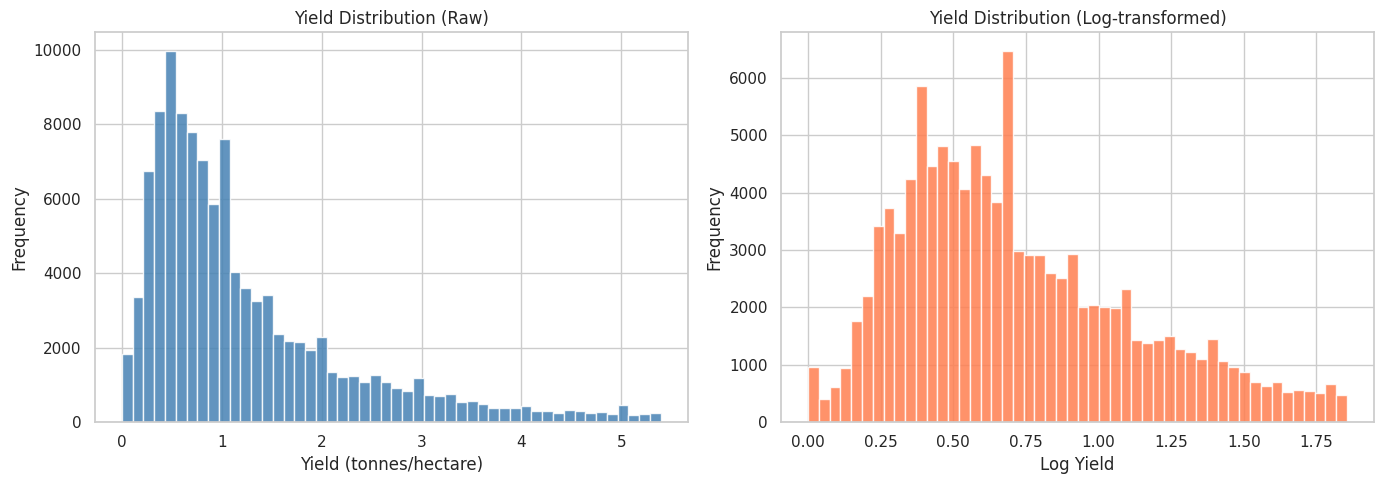

Plot saved: 01_yield_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw yield
axes[0].hist(df['Yield'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Yield Distribution (Raw)')
axes[0].set_xlabel('Yield (tonnes/hectare)')
axes[0].set_ylabel('Frequency')

# Log yield
axes[1].hist(df['Log_Yield'], bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Yield Distribution (Log-transformed)')
axes[1].set_xlabel('Log Yield')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../outputs/plots/01_yield_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 01_yield_distribution.png')

## 2. Top 15 Crops by Average Yield

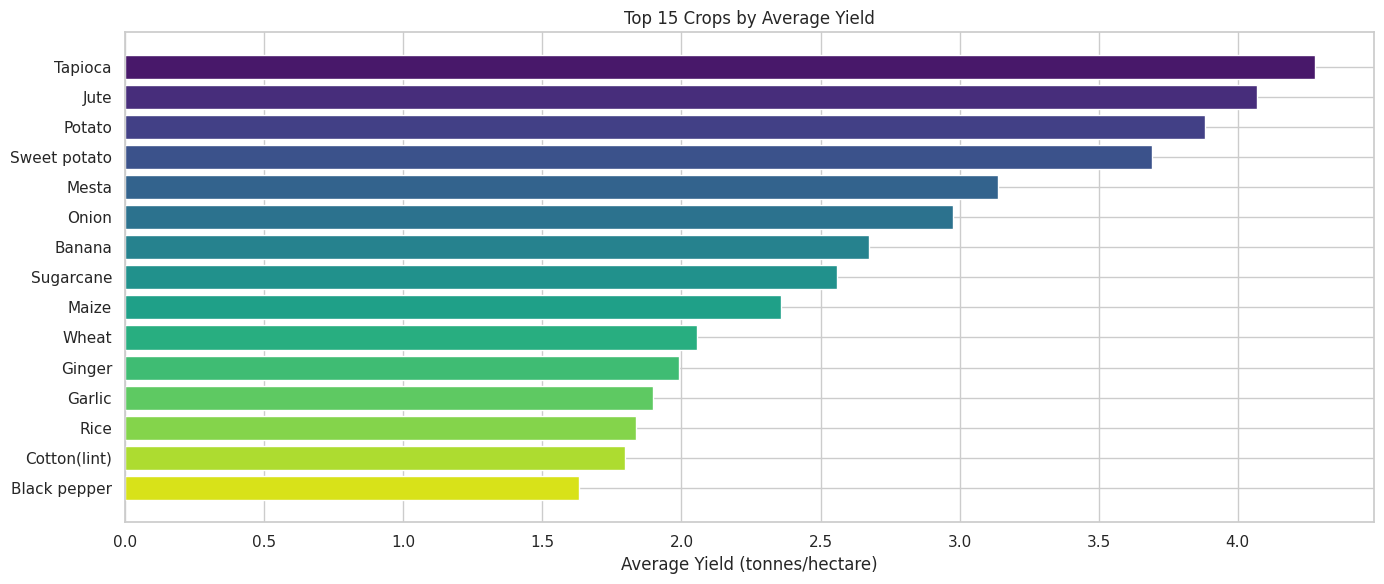

Plot saved: 02_top_crops_yield.png


In [ ]:
top_crops = df.groupby('Crop')['Yield'].mean().sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(14, 6))
bars = plt.barh(top_crops['Crop'], top_crops['Yield'], color=sns.color_palette('viridis', 15))
plt.xlabel('Average Yield (tonnes/hectare)')
plt.title('Top 15 Crops by Average Yield')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/plots/02_top_crops_yield.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 02_top_crops_yield.png')

## 4. Season-wise Average Yield

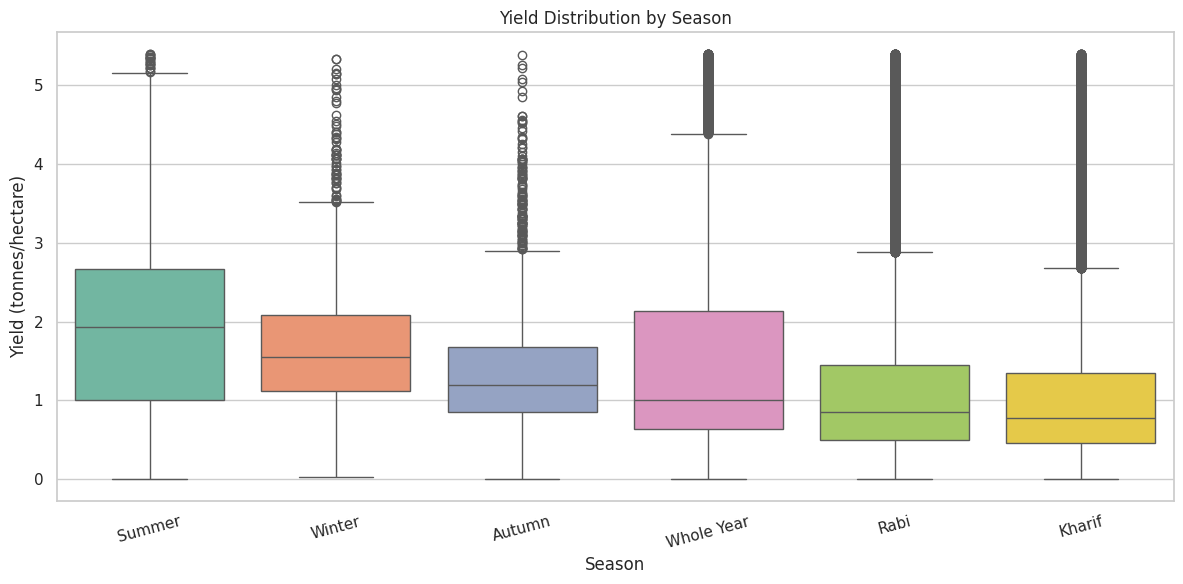

Plot saved: 04_season_yield_boxplot.png


In [ ]:
plt.figure(figsize=(12, 6))
season_order = df.groupby('Season')['Yield'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Season', y='Yield', order=season_order, palette='Set2')
plt.title('Yield Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Yield (tonnes/hectare)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../outputs/plots/04_season_yield_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 04_season_yield_boxplot.png')

## 3. State-wise Average Yield

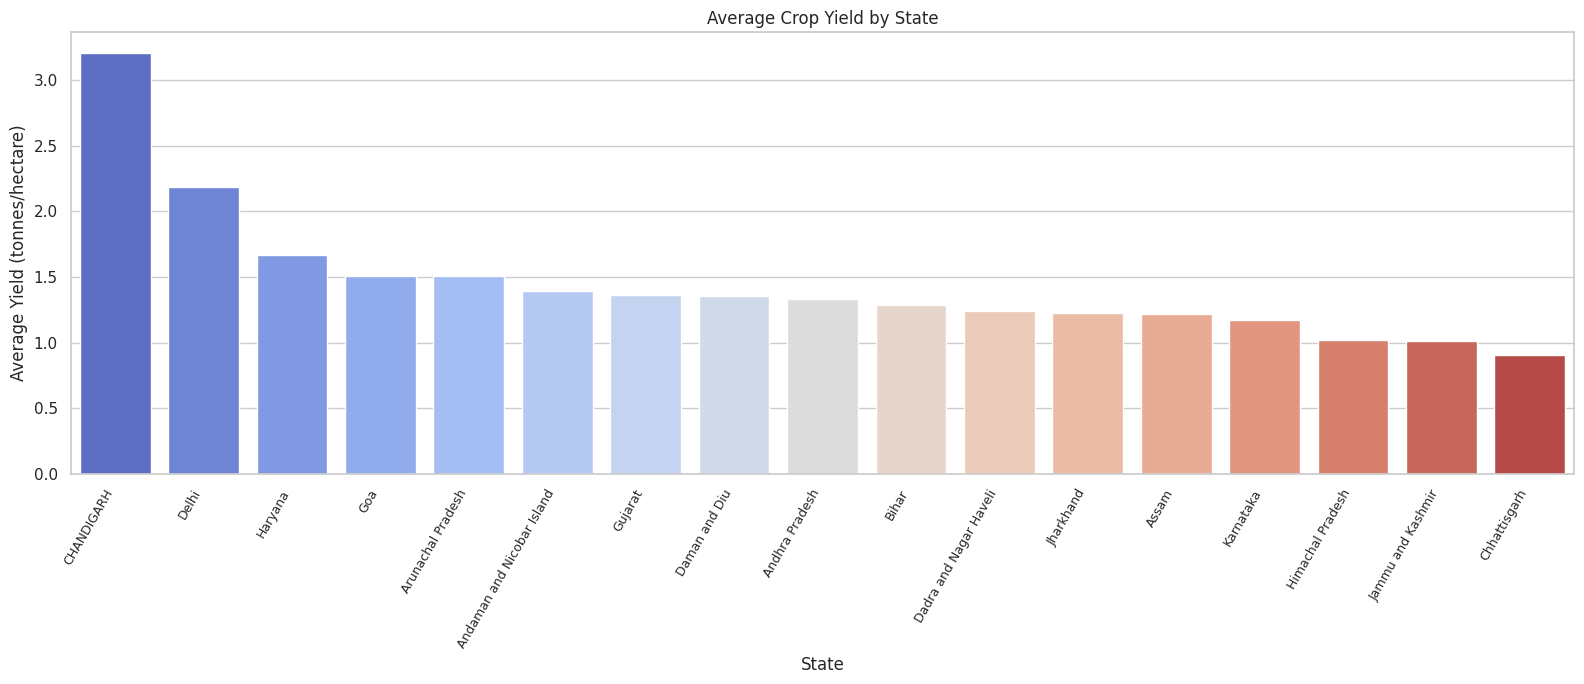

Plot saved: 03_state_wise_yield.png


In [ ]:
state_yield = df.groupby('State')['Yield'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(16, 7))
sns.barplot(data=state_yield, x='State', y='Yield', palette='coolwarm')
plt.xticks(rotation=60, ha='right', fontsize=9)
plt.title('Average Crop Yield by State')
plt.xlabel('State')
plt.ylabel('Average Yield (tonnes/hectare)')
plt.tight_layout()
plt.savefig('../outputs/plots/03_state_wise_yield.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 03_state_wise_yield.png')

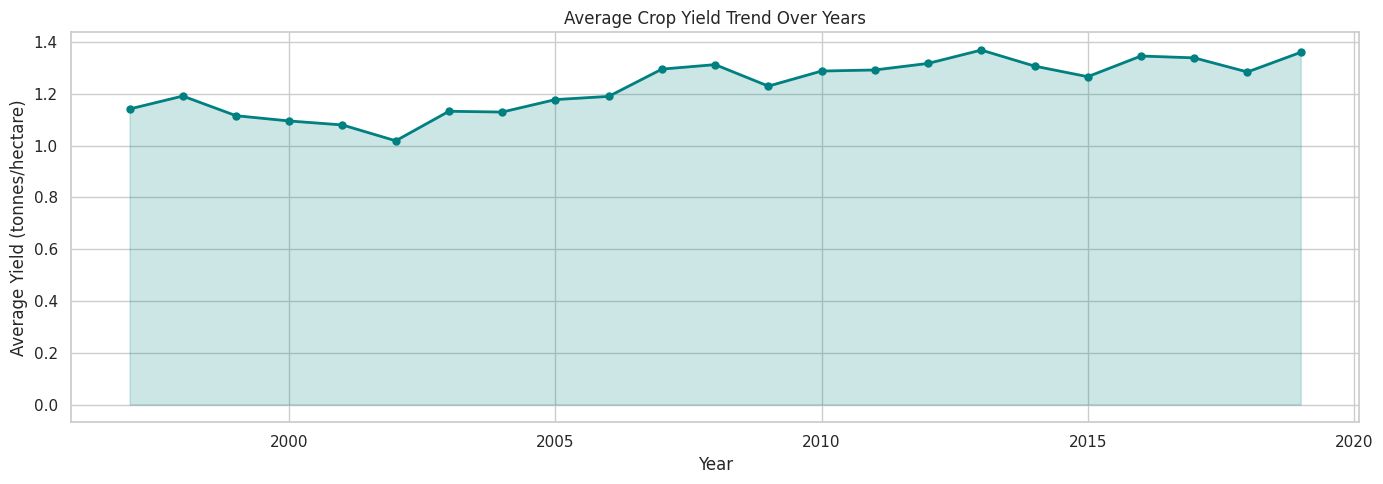

Plot saved: 05_year_wise_trend.png


In [ ]:
year_yield = df.groupby('Crop_Year')['Yield'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(year_yield['Crop_Year'], year_yield['Yield'], marker='o', color='teal', linewidth=2, markersize=5)
plt.fill_between(year_yield['Crop_Year'], year_yield['Yield'], alpha=0.2, color='teal')
plt.title('Average Crop Yield Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Average Yield (tonnes/hectare)')
plt.tight_layout()
plt.savefig('../outputs/plots/05_year_wise_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 05_year_wise_trend.png')

## 6. Correlation Heatmap

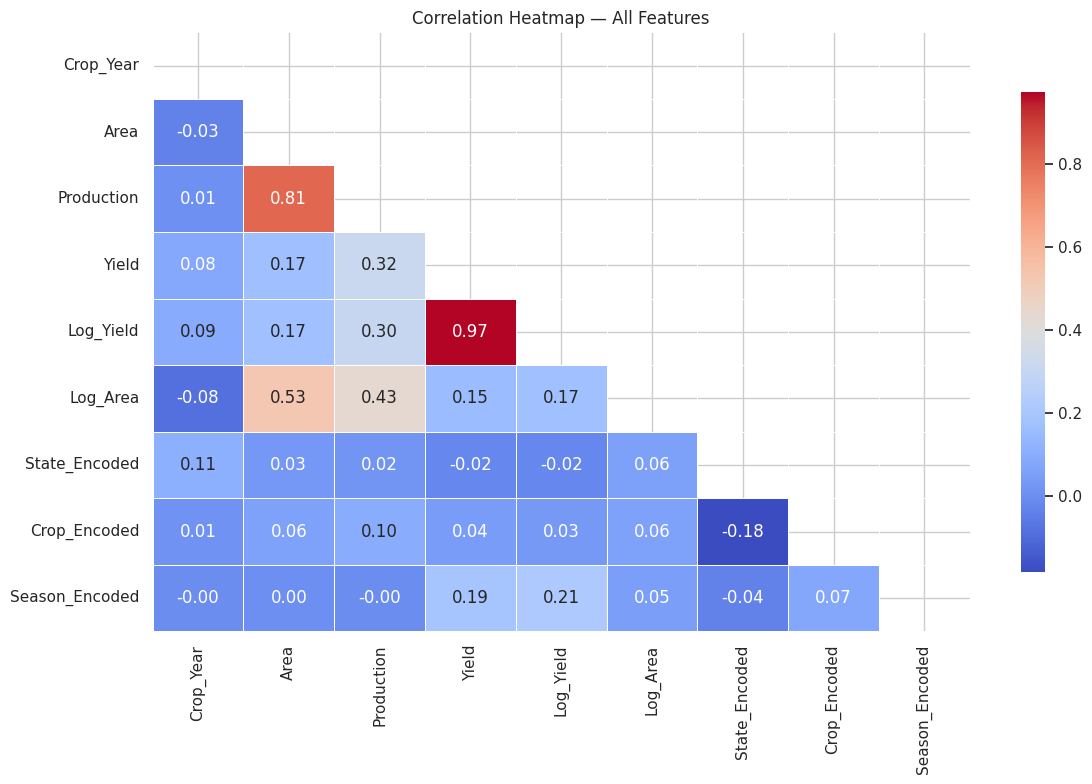

Plot saved: 06_correlation_heatmap.png


In [ ]:
# Select numeric columns for correlation
numeric_cols = ['Crop_Year', 'Area', 'Production', 'Yield', 'Log_Yield', 'Log_Area',
                'State_Encoded', 'Crop_Encoded', 'Season_Encoded']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — All Features')
plt.tight_layout()
plt.savefig('../outputs/plots/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 06_correlation_heatmap.png')

## 8. Crop Category Summary

In [ ]:
crop_counts = df['Crop'].value_counts()
print(crop_counts.head(10))
print(f"\nTotal unique crops: {len(crop_counts)}")

Crop
Maize                8122
Rice                 7979
Moong(Green Gram)    5858
Arhar/Tur            4551
Dry chillies         4507
Wheat                4336
Urad                 4229
Gram                 4219
Groundnut            4190
Rapeseed &Mustard    3957
Name: count, dtype: int64

Total unique crops: 53


## 9. Crop Distribution Pie Chart

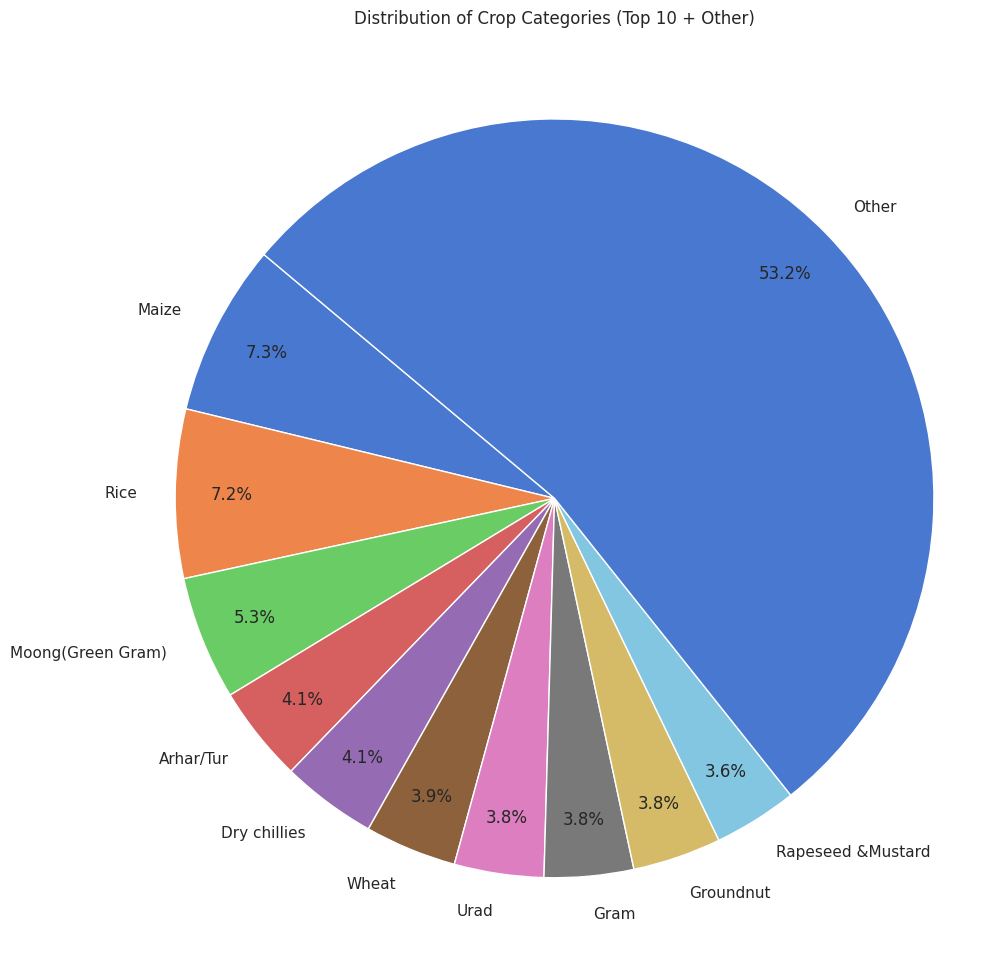

Plot saved: 09_crop_distribution_pie_chart.png


In [ ]:
# Take the top 10 crops and sum the rest as 'Other'
top_10_crops = crop_counts.head(10)
other_crops_sum = crop_counts.iloc[10:].sum()

# Create a new series for plotting
pie_data = pd.concat([top_10_crops, pd.Series({'Other': other_crops_sum})])

plt.figure(figsize=(10, 10))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=140, pctdistance=0.85, wedgeprops={'edgecolor': 'white'})
plt.title('Distribution of Crop Categories (Top 10 + Other)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.savefig('../outputs/plots/09_crop_distribution_pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 09_crop_distribution_pie_chart.png')